# ETA - Deep Neural Network


## Imports


In [ ]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import wget
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout, Input
from tensorflow.keras.models import Sequential

## Constants


In [2]:
DATA_DIR = "../data/v2/"
ZENODO_URL = "https://zenodo.org/records/14895696/files/"

## Load Data


In [3]:
# create data directory if it doesn't exist
os.makedirs(DATA_DIR, exist_ok=True)

# creating dictionary that maps the dataframe to the dataset name
data_map = {
    "fcd_train": "athens_fcd_output_10hour_training",
    "fcd_test": "athens_fcd_output_10hour_testing",
}

# create an empty dictionary to store the dataframes
dataframes = {}

In [4]:
# iterate over the mapping, download the file if it doesn't exist, and load it into the dataframe
for dataframe, dataset in data_map.items():
    filepath = os.path.join(DATA_DIR, dataset + ".csv")
    file_exists = os.path.exists(filepath)
    print(f"Checking {dataset}.")

    if not file_exists:
        url = ZENODO_URL + dataset + ".csv" + "?download=1"
        print("Downloading...")
        wget.download(url, filepath)
        print("Download complete.")
    else:
        print("File already exists, skipping download.")

    # load the data into the dataframe
    dataframes[dataframe] = pd.read_csv(filepath, sep=";")
    print("Loaded into dataframe.\n")

Checking athens_fcd_output_10hour_training.
File already exists, skipping download.
Loaded into dataframe.

Checking athens_fcd_output_10hour_testing.
File already exists, skipping download.
Loaded into dataframe.



In [5]:
fcd_train = dataframes["fcd_train"]
fcd_test = dataframes["fcd_test"]

fcd_train

,timestep_time,vehicle_angle,vehicle_id,vehicle_lane,vehicle_pos,vehicle_slope,vehicle_speed,vehicle_type,vehicle_x,vehicle_y
0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7870056,35999.0,318.70,veh1584,-224027778_0,6.05,0.0,5.35,car,1998.14,340.00
7870057,35999.0,95.94,veh1585,201375091#0_0,47.46,0.0,11.77,car,2627.70,457.05
7870058,35999.0,19.40,veh1586,31619891#5_0,10.58,0.0,2.24,car,456.04,1021.12
7870059,35999.0,314.58,veh1587,101001101_0,13.17,0.0,1.07,bus,1910.75,192.01


## Data Cleaning


In [6]:
# remove rows where vehicle_id is NaN
fcd_train = fcd_train[~fcd_train["vehicle_id"].isna()]
fcd_test = fcd_test[~fcd_test["vehicle_id"].isna()]

In [7]:
# remove columns that are not useful for trips
fcd_train = fcd_train.drop(columns=["vehicle_angle", "vehicle_lane", "vehicle_pos", "vehicle_slope", "vehicle_speed"])
fcd_test = fcd_test.drop(columns=["vehicle_angle", "vehicle_lane", "vehicle_pos", "vehicle_slope", "vehicle_speed"])

In [8]:
fcd_train

,timestep_time,vehicle_id,vehicle_type,vehicle_x,vehicle_y
12,12.0,veh0,bus,266.91,1136.32
13,13.0,veh0,bus,266.16,1135.54
14,14.0,veh0,bus,264.61,1133.97
15,15.0,veh0,bus,262.09,1131.39
16,16.0,veh0,bus,258.85,1128.08
...,...,...,...,...,...
7870056,35999.0,veh1584,car,1998.14,340.00
7870057,35999.0,veh1585,car,2627.70,457.05
7870058,35999.0,veh1586,car,456.04,1021.12
7870059,35999.0,veh1587,bus,1910.75,192.01


## Exploratory Data Analysis


### Vehicles per Second


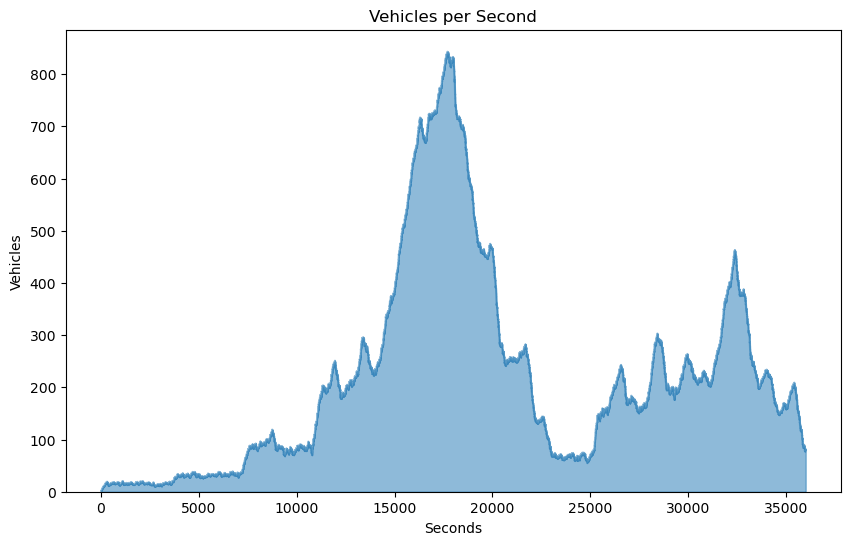

In [9]:
# calculate vehicles per second
vehicles_per_second = fcd_train.groupby("timestep_time").size()

# plot vehicles per second
plt.figure(figsize=(10, 6))
vehicles_per_second.plot.area(alpha=0.5)
plt.title("Vehicles per Second")
plt.xlabel("Seconds")
plt.ylabel("Vehicles")
plt.show()

### Vehicle Type


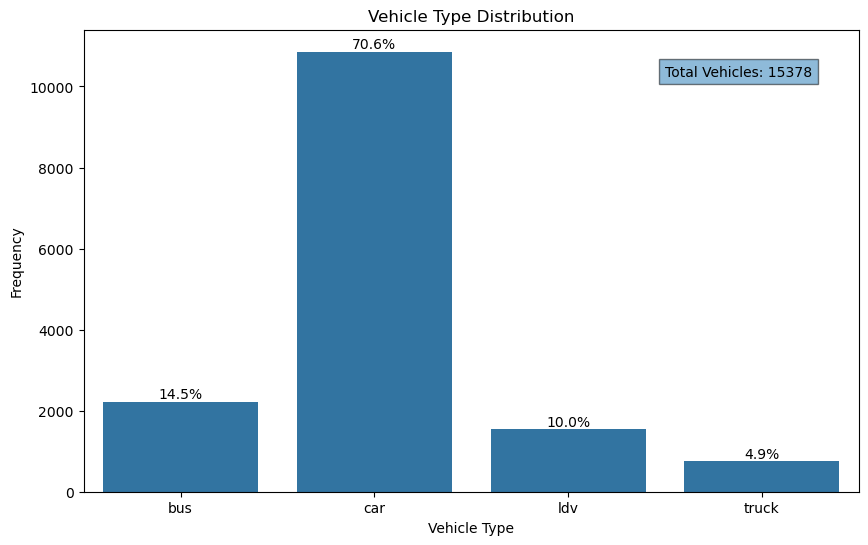

In [10]:
# calculate unique vehicle types
unique_vehicle_types = fcd_train[["vehicle_id", "vehicle_type"]].drop_duplicates()

plt.figure(figsize=(10, 6))
ax = sns.countplot(x="vehicle_type", data=unique_vehicle_types)
plt.title("Vehicle Type Distribution")
plt.xlabel("Vehicle Type")
plt.ylabel("Frequency")

counts = len(unique_vehicle_types)
for c in ax.containers:
    ax.bar_label(c, fmt=lambda x: f"{x / counts:.1%}")

plt.text(0.75, 0.9, f"Total Vehicles: {counts}", transform=ax.transAxes, bbox={"alpha": 0.5})
plt.show()

### Spatial Distribution


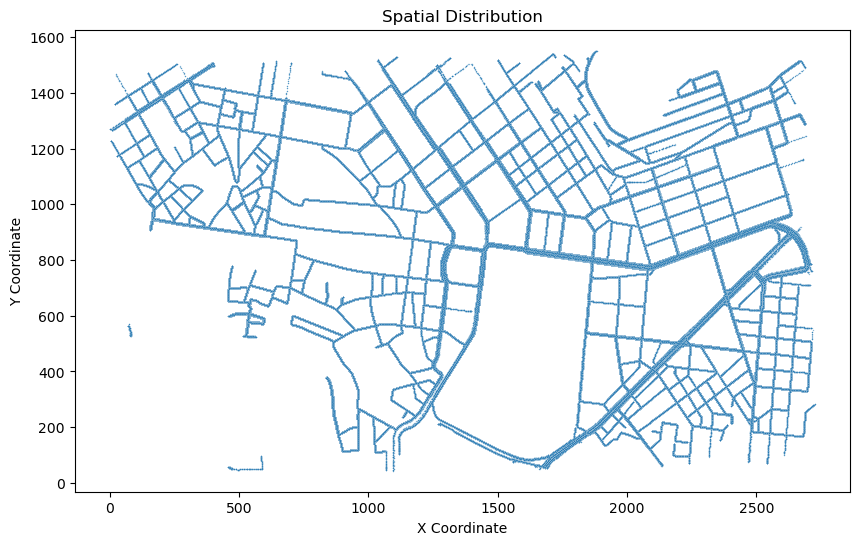

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="vehicle_x", y="vehicle_y", data=fcd_train, s=1, alpha=0.5)
plt.title("Spatial Distribution")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()

### Trip Durations


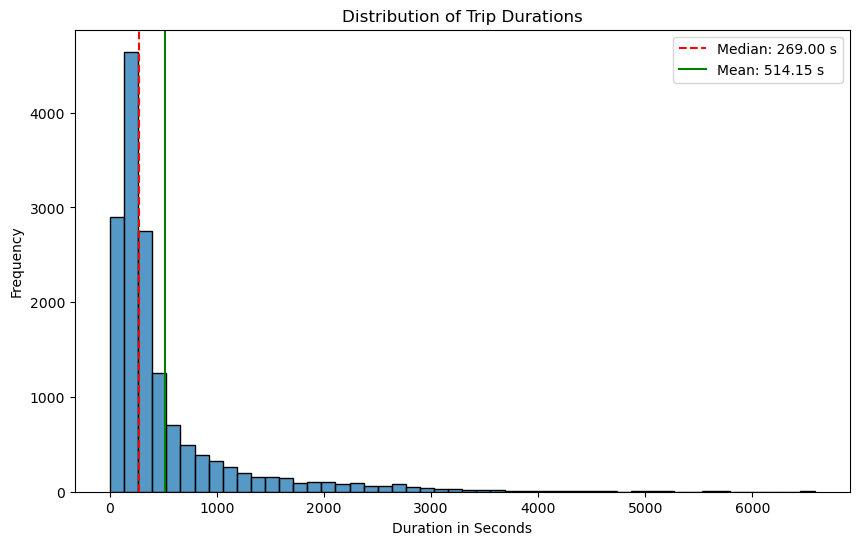

In [12]:
# calculate trip durations
trip_durations = fcd_train.groupby("vehicle_id").agg({"timestep_time": ["min", "max"]})

# flatten the multi-level columns
trip_durations.columns = ["start_time", "end_time"]
trip_durations["duration_seconds"] = trip_durations["end_time"] - trip_durations["start_time"]

# plot the distribution of trip durations
plt.figure(figsize=(10, 6))
sns.histplot(trip_durations["duration_seconds"], bins=50)
plt.title("Distribution of Trip Durations")
plt.xlabel("Duration in Seconds")
plt.ylabel("Frequency")
plt.axvline(
    x=trip_durations["duration_seconds"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {trip_durations['duration_seconds'].median():.2f} s",
)
plt.axvline(
    x=trip_durations["duration_seconds"].mean(),
    color="green",
    linestyle="-",
    label=f"Mean: {trip_durations['duration_seconds'].mean():.2f} s",
)
plt.legend()
plt.show()

## Feature Engineering


In [13]:
# add hour of day column based on timestamp in seconds
fcd_train["hour_of_day"] = (fcd_train["timestep_time"] // 3600).astype(int)
fcd_test["hour_of_day"] = (fcd_test["timestep_time"] // 3600).astype(int)

In [14]:
# one hot encode vehicle_type to numerical
fcd_train = pd.get_dummies(fcd_train, columns=["vehicle_type"], dtype="float")
fcd_test = pd.get_dummies(fcd_test, columns=["vehicle_type"], dtype="float")

In [15]:
fcd_train

,timestep_time,vehicle_id,vehicle_x,vehicle_y,hour_of_day,vehicle_type_bus,vehicle_type_car,vehicle_type_ldv,vehicle_type_truck
12,12.0,veh0,266.91,1136.32,0,1.0,0.0,0.0,0.0
13,13.0,veh0,266.16,1135.54,0,1.0,0.0,0.0,0.0
14,14.0,veh0,264.61,1133.97,0,1.0,0.0,0.0,0.0
15,15.0,veh0,262.09,1131.39,0,1.0,0.0,0.0,0.0
16,16.0,veh0,258.85,1128.08,0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
7870056,35999.0,veh1584,1998.14,340.00,9,0.0,1.0,0.0,0.0
7870057,35999.0,veh1585,2627.70,457.05,9,0.0,1.0,0.0,0.0
7870058,35999.0,veh1586,456.04,1021.12,9,0.0,1.0,0.0,0.0
7870059,35999.0,veh1587,1910.75,192.01,9,1.0,0.0,0.0,0.0


## Construct Trips DataFrame


In [16]:
# function that constructs a trip based on a group of timestamps for a vehicle_id
def construct_trip(group):
    group_sorted = group.sort_values("timestep_time")
    first_row = group_sorted.iloc[0]
    last_row = group_sorted.iloc[-1]

    return pd.Series(
        {
            "start_x": first_row["vehicle_x"],
            "start_y": first_row["vehicle_y"],
            "destination_x": last_row["vehicle_x"],
            "destination_y": last_row["vehicle_y"],
            "hour_of_day": group["hour_of_day"].mode()[0],
            "vehicle_type_bus": first_row["vehicle_type_bus"],
            "vehicle_type_car": first_row["vehicle_type_car"],
            "vehicle_type_ldv": first_row["vehicle_type_ldv"],
            "vehicle_type_truck": first_row["vehicle_type_truck"],
            "trip_duration": last_row["timestep_time"] - first_row["timestep_time"],
        }
    )


# group by vehicle_id and construct the trips dataframe
trips_train = fcd_train.groupby("vehicle_id").apply(construct_trip, include_groups=False).reset_index()
trips_test = fcd_test.groupby("vehicle_id").apply(construct_trip, include_groups=False).reset_index()

In [17]:
trips_train

,vehicle_id,start_x,start_y,destination_x,destination_y,hour_of_day,vehicle_type_bus,vehicle_type_car,vehicle_type_ldv,vehicle_type_truck,trip_duration
0,veh0,266.91,1136.32,2495.35,381.74,0.0,1.0,0.0,0.0,0.0,342.0
1,veh1,433.71,1323.05,2238.10,224.42,0.0,0.0,1.0,0.0,0.0,312.0
2,veh10,554.95,600.75,2140.55,947.22,0.0,1.0,0.0,0.0,0.0,544.0
3,veh100,1796.03,1429.95,2007.19,234.24,0.0,0.0,1.0,0.0,0.0,246.0
4,veh1000,2386.95,638.63,2457.40,452.88,9.0,0.0,0.0,1.0,0.0,59.0
...,...,...,...,...,...,...,...,...,...,...,...
15373,veh9995,2096.93,186.71,1948.17,259.32,6.0,0.0,0.0,1.0,0.0,71.0
15374,veh9996,2095.41,771.68,555.30,991.85,6.0,0.0,1.0,0.0,0.0,228.0
15375,veh9997,2043.88,1166.53,2630.04,980.08,6.0,0.0,1.0,0.0,0.0,113.0
15376,veh9998,2502.36,423.10,2365.00,1427.68,6.0,0.0,1.0,0.0,0.0,170.0


## Features and Target


In [ ]:
# define features and target columns
feature_cols = [col for col in trips_train.columns if col not in ["vehicle_id", "trip_duration"]]
target_col = "trip_duration"

# split into X and y for training and testing
X_train = trips_train[feature_cols]
y_train = trips_train[target_col]
X_test = trips_test[feature_cols]
y_test = trips_test[target_col]

## Scaling


In [21]:
# scale the features using a standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Deep Neural Network


In [52]:
# build a deep neural network model for regression
model = Sequential(
    [
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),
        Dense(16, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),
        Dense(1),
    ]
)

# compile the model using the adam optimizer and mean absolute error loss
model.compile(optimizer="adam", loss="mean_absolute_error")

# set up early stopping to prevent overfitting
early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

# train the model
history = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=200, batch_size=64, callbacks=[early_stop])

Epoch 1/200
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 465.3022 - val_loss: 756.2069
Epoch 2/200
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 450.3687 - val_loss: 751.2311
Epoch 3/200
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 447.8254 - val_loss: 744.0027
Epoch 4/200
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 434.2919 - val_loss: 732.7155
Epoch 5/200
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 436.7020 - val_loss: 718.8348
Epoch 6/200
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 405.8629 - val_loss: 701.9620
Epoch 7/200
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 389.4457 - val_loss: 681.0018
Epoch 8/200
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 391.7657 - val_loss: 663.0631
Epoch 9/200
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 365.2212 - val_loss: 643.1085
Epoch 10/200
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 333.4905 - val_loss: 615.5477
Epoch 11/200
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 319.5240 - val_loss: 600.00

In [53]:
# evaluate the model on the test set
test_mae = model.evaluate(X_test_scaled, y_test)
print(f"Test MAE: {test_mae}\n")

# make predictions on the test set
y_pred = model.predict(X_test_scaled)
predictions_dnn = pd.DataFrame({"Actual Duration": y_test, "Predicted Duration": y_pred.flatten()})
predictions_dnn

492/492 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step - loss: 175.2166
Test MAE: 271.44970703125

492/492 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step


,Actual Duration,Predicted Duration
0,294.0,345.794861
1,362.0,333.229614
2,620.0,361.823669
3,235.0,207.084930
4,1730.0,415.086426
...,...,...
15720,419.0,475.631775
15721,568.0,846.401855
15722,356.0,693.492737
15723,347.0,1773.538940
